# Predicting Student Dropout & Academic Success — A Classification Capstone

**Author:** Simone Rossi  
**Dataset:** *Predict Students' Dropout and Academic Success* — UCI Machine Learning Repository (Realinho et al., 2021)

> **One-line framing.** We build a *decision-support* classifier that flags students at
> risk of **dropping out** early enough for universities to offer help, and this should be not used as a tool for
> exclusion or automated decisions.

---

### How to read this notebook

This notebook follows a standard, end-to-end data-science workflow. Each analytical
step is introduced by a short markdown cell stating **why** the step is taken, and is
followed by an interpretation of **what the result means for real-world decisions**.

| # | Section | Purpose |
|---|---------|---------|
| 1 | Problem framing & motivation | Why the problem matters and what exactly we predict |
| 2 | Data & stakeholder context | Provenance, licence, features, ethics, known risks |
| 3 | Data loading & initial inspection | Load the raw data and verify its integrity |
| 4 | Data cleaning & preprocessing | Missing values, duplicates, types, leakage strategy |
| 5 | Exploratory data analysis | Distributions, missingness, predictor–target patterns |
| 6 | Feature strategy & engineering | Encoding, scaling, timing, and a justified derived feature |
| 7 | Modelling approach | Baseline + three models inside leakage-safe pipelines |
| 8 | Model comparison & diagnostics | Cross-validation, tuning, confusion/ROC/importance |
| 9 | Evaluation, robustness & fairness | Timing trade-off, thresholds, subgroup & calibration checks |
| 10 | Recommendation & implications | Final model, deployment guardrails, limitations, references |



## 1. Problem Framing & Motivation

### 1.1 The problem
Roughly one in three students who enter higher education in the EU leave without
completing their degree. Dropout is costly on every side: students lose time, money and
future earnings; universities lose tuition, funding tied to completion rates, and the
return on the support they already invested; and society loses skilled graduates and a
measure of social mobility. Crucially, dropout is often **predictable and preventable**: warning signs (failed units, unpaid fees, disengagement) usually appear *before* a student
leaves. The value of a model is therefore not prediction for its own sake, but **buying time
for intervention**.

### 1.2 The prediction target
We frame this as a **multi-class classification** task. For each student we predict the
academic outcome recorded at the end of the normal course duration:

- **Dropout**: left without graduating (the class we most want to catch),
- **Enrolled**: still studying, outcome not yet resolved,
- **Graduate**: completed successfully.

### 1.3 Stakeholders & realistic decision scenarios
| Stakeholder | Decision the model supports | Cost of a missed dropout (false negative) |
|-------------|-----------------------------|-------------------------------------------|
| **Student support / advising teams** | Which students to contact first for tutoring, mentoring or wellbeing check-ins | A struggling student is never contacted and leaves |
| **Financial aid office** | Who to prioritise for emergency bursaries or fee-payment plans | A student drops out over a solvable financial issue |
| **Programme directors** | Which cohorts/courses need curriculum or workload review | Systemic problems stay invisible |
| **University leadership / policy** | Where to invest limited retention budget | Resources spread thinly, retention stalls |

In every scenario the model **ranks and prioritises** scarce human attention. A *false
negative* (an at-risk student flagged as safe) is far more damaging than a *false positive*
(a safe student who receives an unneeded, supportive email). This asymmetry drives our
choice of evaluation metrics (§9) toward **recall on the Dropout class**.

### 1.4 Why it matters — social & ethical framing
Retention is a lever for **equity**. Dropout falls hardest on students from disadvantaged
backgrounds, so a well-governed early-warning system directly supports **UN Sustainable
Development Goal 4 (Quality Education)**. The same power is a risk: a biased or misused
model could label and disadvantage the very students it should help. We therefore commit
up front to (a) using the model only to *offer* support, (b) auditing error rates across
demographic subgroups (§9), and (c) keeping a human in the loop.

### 1.5 Hypothesis
> A supervised classifier trained on enrolment, socioeconomic and early-academic data will
> predict student outcomes **substantially better than a majority-class baseline**,
> and in particular will achieve **useful recall for the Dropout class**, making it fit for
> early-intervention decision support.

This hypothesis is tested explicitly in §7–§9: we compute the majority-class baseline (not
just assert it), compare three models by cross-validation, and report Dropout recall
against it.


## 2. Data Description & Stakeholder Context

### 2.1 Source, licence and citation
- **Dataset:** *Predict Students' Dropout and Academic Success*, UCI Machine Learning Repository.
- **Link:** https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
- **Licence:** Creative Commons **CC BY 4.0** — free to share and adapt with attribution.
- **Citation:** Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021).
  *Predict Students' Dropout and Academic Success* [Dataset]. UCI ML Repository.
  https://doi.org/10.24432/C5MC89

The data comes from a Portuguese higher-education institution and covers **4,424 students**
across 17 undergraduate programmes, with **36 features** plus the target. Each row is one
student; features are known at enrolment or measured across the first two semesters.

### 2.2 Feature groups (and why each may help)
| Group | Example fields | Signal for the model |
|-------|----------------|----------------------|
| **Prior academic** | Admission grade, Previous qualification (grade) | Preparation on entry |
| **Enrolment / programme** | Course, Application mode/order, Day/evening attendance | Fit, motivation, workload context |
| **Demographic** *(sensitive)* | Gender, Age at enrolment, Nationality, International | Different risk patterns — **must be fairness-audited** |
| **Socioeconomic** *(sensitive proxies)* | Parents' qualification/occupation, Marital status, Displaced | Home support & structural disadvantage |
| **Financial** | Debtor, Tuition fees up to date, Scholarship holder | Often the *actionable* driver of dropout |
| **1st-semester performance** | Units credited/enrolled/approved/grade | Earliest strong academic signal |
| **2nd-semester performance** | Units credited/enrolled/approved/grade | Stronger but **later** — a timing/leakage trade-off |
| **Macroeconomic** | Unemployment, Inflation, GDP | External financial pressure |

### 2.3 Known risks we will manage
1. **Class imbalance.** Graduate ≈ 50%, Dropout ≈ 32%, Enrolled ≈ 18%. Accuracy alone is
   misleading; we lead with **macro-F1, balanced accuracy and Dropout recall**.
2. **Timing / leakage.** Second-semester features are highly predictive but only available
   *late*. For genuine *early* intervention we build and compare an **enrolment + 1st-semester
   model** against the **full model** (§9.1).
3. **Sensitive attributes.** Demographic and socioeconomic fields can encode structural
   inequality. We keep them for predictive value but **audit subgroup error rates** (§9.3).
4. **Generalisability.** One institution, one country — any deployment needs local revalidation.


## 3. Reusable Data Pipeline, Loading & Initial Inspection

**Purpose.** Before any analysis we stand up a small, **reusable data-engineering pipeline**
that can ingest raw data from *different sources*, automatically **detect data-quality
problems**, **clean and transform** the data, **validate** the result against declared
expectations, and **export** an analytics-ready dataset. The same objects work for a new CSV,
an Excel export, a JSON dump, a Parquet file, or a SQL table — only the *configuration*
changes. We then run this pipeline on the student dataset and manually inspect the output to
confirm what the pipeline reports.

The setup cell below fixes a global random seed, a consistent plotting style, and a
`save_fig` helper so **every chart in this notebook is exported to the `charts/` folder**.

### Pipeline architecture

```mermaid
flowchart LR
    A[Raw sources<br/>CSV · Excel · JSON<br/>Parquet · SQL] --> B[Ingest]
    B --> C[Profile<br/>detect quality issues]
    C --> D[Clean & transform]
    D --> E[Validate<br/>against expectations]
    E --> F[Export<br/>analytics-ready CSV]
    F --> G[EDA · ML · Warehouse]
```


In [1]:
# --- Environment & reproducibility -----------------------------------------
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"  # keep parallel (loky) workers quiet too

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Human-readable class labels (fixed order used everywhere in the notebook)
CLASS_LABELS = ["Dropout", "Enrolled", "Graduate"]

# --- Project paths & a reusable chart-export helper -------------------------
# Resolve the project root robustly whether the notebook runs from /notebook,
# the project root, or Colab. Every figure is saved into CHARTS_DIR.
def _resolve_project_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "data").exists() and (base / "charts").exists():
            return base
        if (base / "notebook").exists() and (base / "data").exists():
            return base
    return here

PROJECT_ROOT = _resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data"
CHARTS_DIR = PROJECT_ROOT / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None, dpi: int = 150) -> Path:
    """Save the current (or given) figure to CHARTS_DIR as a PNG and return its path."""
    fig = fig or plt.gcf()
    path = CHARTS_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

print("Libraries loaded. Random seed =", RANDOM_STATE)
print("Project root :", PROJECT_ROOT)
print("Charts dir   :", CHARTS_DIR)


Libraries loaded. Random seed = 42
Project root : /content
Charts dir   : /content/charts


In [2]:
import os
p = "/Users/simonerossi/Documents/ToU/Classification/student prediction"
print("workspace visible from kernel:", os.path.exists(p))
print(os.listdir(p) if os.path.exists(p) else "N/A")


workspace visible from kernel: False
N/A


### 3.1 A config-driven pipeline in five decoupled stages

The pipeline is intentionally small and **framework-free** so it is easy to read, test and
reuse. All source-specific knowledge is isolated in a single `PipelineConfig`; the stage
classes never hard-code anything about the student data.

| Stage | Class | Responsibility |
|-------|-------|----------------|
| 1 · Ingest | `DataIngestor` | Read CSV / Excel / JSON / Parquet / SQLite into a DataFrame (delimiter auto-sniffed) |
| 2 · Profile | `DataProfiler` | Detect missing cells, duplicates, whitespace headers, constant & high-cardinality columns, numeric-stored-as-text, IQR outliers |
| 3 · Clean | `DataCleaner` | Trim headers, drop duplicates, strip strings, coerce types, apply a missing-value policy — every action is logged |
| 4 · Validate | `DataValidator` | Assert schema, non-null, uniqueness, value-range and domain expectations; returns pass/fail |
| 5 · Export | `DataExporter` | Persist the analytics-ready dataset (clean CSV) |

**Reusing it for another source** is a one-liner — for example a database table:

```python
cfg = PipelineConfig(source="warehouse.db", source_type="sqlite",
                     read_options={"table": "students"}, output_csv="out.csv")
clean = DataPipeline(cfg).run()
```


In [3]:
# --- 3.1 A reusable, config-driven data-engineering pipeline ----------------
# Five decoupled stages (ingest -> profile -> clean -> validate -> export).
# All source-specific knowledge lives in PipelineConfig, so the same classes
# work for any tabular source by changing only the configuration.
import re
import sqlite3
from dataclasses import dataclass, field


@dataclass
class PipelineConfig:
    """Single source of truth for everything source-specific."""
    source: str                                        # file path or SQLite db path
    source_type: str = "auto"                          # auto|csv|excel|json|parquet|sqlite
    read_options: dict = field(default_factory=dict)   # e.g. {"sep": ";"} or {"table": "..."}
    # cleaning knobs
    strip_column_whitespace: bool = True
    standardize_column_names: bool = False             # snake_case headers if True
    drop_duplicate_rows: bool = True
    strip_string_values: bool = True
    coerce_numeric: bool = True                        # text columns that are really numbers
    dtype_overrides: dict = field(default_factory=dict)
    missing_strategy: str = "flag"                     # flag|drop_rows|fill
    fill_values: dict = field(default_factory=dict)
    # validation expectations
    required_columns: list = field(default_factory=list)
    non_null_columns: list = field(default_factory=list)
    unique_row_key: list = field(default_factory=list)
    value_ranges: dict = field(default_factory=dict)   # {col: (min, max)}
    allowed_values: dict = field(default_factory=dict) # {col: [allowed values]}
    min_rows: int = 1
    # output
    output_csv: str = None


class DataIngestor:
    """Stage 1 — read raw data from heterogeneous sources into a DataFrame."""
    def __init__(self, config: PipelineConfig):
        self.config = config

    def _infer_type(self) -> str:
        if self.config.source_type != "auto":
            return self.config.source_type
        s = str(self.config.source).lower()
        if s.endswith((".xlsx", ".xls")):              return "excel"
        if s.endswith(".json"):                        return "json"
        if s.endswith(".parquet"):                     return "parquet"
        if s.endswith((".db", ".sqlite", ".sqlite3")): return "sqlite"
        return "csv"

    @staticmethod
    def _sniff_sep(path: str) -> str:
        import csv as _csv
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            sample = fh.read(4096)
        try:
            return _csv.Sniffer().sniff(sample, delimiters=";,|\t").delimiter
        except Exception:
            return ","

    def load(self) -> pd.DataFrame:
        stype = self._infer_type()
        opts = dict(self.config.read_options)
        if stype == "csv":
            sep = opts.pop("sep", None) or self._sniff_sep(self.config.source)
            return pd.read_csv(self.config.source, sep=sep, engine="python", **opts)
        if stype == "excel":
            return pd.read_excel(self.config.source, **opts)
        if stype == "json":
            return pd.read_json(self.config.source, **opts)
        if stype == "parquet":
            return pd.read_parquet(self.config.source, **opts)
        if stype == "sqlite":
            query = opts.pop("query", None)
            table = opts.pop("table", None)
            with sqlite3.connect(self.config.source) as conn:
                return pd.read_sql_query(query or f"SELECT * FROM {table}", conn, **opts)
        raise ValueError(f"Unsupported source_type: {stype}")


class DataProfiler:
    """Stage 2 — detect data-quality problems and return a structured report."""
    def __init__(self, config: PipelineConfig):
        self.config = config

    def profile(self, df: pd.DataFrame) -> dict:
        n_rows, n_cols = df.shape
        missing = df.isna().sum()
        obj_cols = df.select_dtypes(include="object").columns
        report = {
            "n_rows": int(n_rows),
            "n_cols": int(n_cols),
            "total_missing_cells": int(missing.sum()),
            "duplicate_rows": int(df.duplicated().sum()),
            "columns_with_whitespace_headers": [c for c in df.columns if c != str(c).strip()],
            "missing_by_column": {c: int(v) for c, v in missing[missing > 0].items()},
            "constant_columns": [c for c in df.columns if df[c].nunique(dropna=False) <= 1],
            "high_cardinality_columns": [
                c for c in obj_cols if df[c].nunique(dropna=False) > 0.5 * max(n_rows, 1)
            ],
            "numeric_columns": df.select_dtypes(include="number").columns.tolist(),
            "object_columns": obj_cols.tolist(),
        }
        # numeric values accidentally stored as text (a common ingestion problem)
        text_numeric = []
        for c in obj_cols:
            coerced = pd.to_numeric(df[c], errors="coerce")
            if df[c].notna().any() and coerced.notna().mean() > 0.95:
                text_numeric.append(c)
        report["numeric_stored_as_text"] = text_numeric
        # IQR outlier scan on numeric columns
        outliers = {}
        for c in report["numeric_columns"]:
            s = df[c].dropna()
            if s.empty:
                continue
            q1, q3 = s.quantile([0.25, 0.75])
            iqr = q3 - q1
            if iqr == 0:
                continue
            n_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
            if n_out:
                outliers[c] = n_out
        report["outlier_counts_iqr"] = outliers
        return report


class DataCleaner:
    """Stage 3 — deterministic, config-driven cleaning & transformation."""
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.actions = []

    @staticmethod
    def _to_snake(name: str) -> str:
        s = re.sub(r"[^0-9a-zA-Z]+", "_", str(name).strip()).strip("_").lower()
        return re.sub(r"_+", "_", s)

    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        cfg, out = self.config, df.copy()
        if cfg.strip_column_whitespace:
            new_cols = out.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            renamed = int((new_cols != out.columns).sum())
            out.columns = new_cols
            if renamed:
                self.actions.append(f"Trimmed whitespace in {renamed} column header(s)")
        if cfg.standardize_column_names:
            out.columns = [self._to_snake(c) for c in out.columns]
            self.actions.append("Standardised column names to snake_case")
        if cfg.strip_string_values:
            obj = out.select_dtypes(include="object").columns
            for c in obj:
                out[c] = out[c].astype(str).str.strip().replace({"nan": np.nan})
            if len(obj):
                self.actions.append(f"Stripped whitespace in {len(obj)} text column(s)")
        if cfg.drop_duplicate_rows:
            before = len(out)
            out = out.drop_duplicates().reset_index(drop=True)
            if before - len(out):
                self.actions.append(f"Dropped {before - len(out)} duplicate row(s)")
        if cfg.coerce_numeric:
            for c in out.select_dtypes(include="object").columns:
                coerced = pd.to_numeric(out[c], errors="coerce")
                if out[c].notna().any() and coerced.notna().mean() > 0.95:
                    out[c] = coerced
                    self.actions.append(f"Coerced '{c}' to numeric")
        for c, dt in cfg.dtype_overrides.items():
            if c in out.columns:
                out[c] = out[c].astype(dt)
                self.actions.append(f"Cast '{c}' -> {dt}")
        if cfg.missing_strategy == "drop_rows":
            before = len(out)
            out = out.dropna().reset_index(drop=True)
            if before - len(out):
                self.actions.append(f"Dropped {before - len(out)} row(s) with missing values")
        elif cfg.missing_strategy == "fill":
            out = out.fillna(cfg.fill_values)
            self.actions.append("Filled missing values from config")
        if not self.actions:
            self.actions.append("No cleaning changes were required")
        return out


class DataValidator:
    """Stage 4 — assert the cleaned data meets declared expectations."""
    def __init__(self, config: PipelineConfig):
        self.config = config

    def validate(self, df: pd.DataFrame) -> dict:
        cfg, checks = self.config, []

        def add(name, passed, detail=""):
            checks.append({"check": name, "passed": bool(passed), "detail": detail})

        add("row_count_minimum", len(df) >= cfg.min_rows,
            f"{len(df)} rows (min {cfg.min_rows})")
        missing_required = [c for c in cfg.required_columns if c not in df.columns]
        add("required_columns_present", not missing_required, f"missing: {missing_required}")
        for c in cfg.non_null_columns:
            if c in df.columns:
                n = int(df[c].isna().sum())
                add(f"non_null[{c}]", n == 0, f"{n} null(s)")
        if cfg.unique_row_key:
            key = [c for c in cfg.unique_row_key if c in df.columns]
            if key:
                d = int(df.duplicated(subset=key).sum())
                add("unique_row_key", d == 0, f"{d} duplicate key(s)")
        add("no_duplicate_rows", df.duplicated().sum() == 0,
            f"{int(df.duplicated().sum())} duplicate row(s)")
        for c, (lo, hi) in cfg.value_ranges.items():
            if c in df.columns:
                bad = int(((df[c] < lo) | (df[c] > hi)).sum())
                add(f"range[{c}]", bad == 0, f"{bad} value(s) outside [{lo}, {hi}]")
        for c, allowed in cfg.allowed_values.items():
            if c in df.columns:
                bad = int((~df[c].isin(list(allowed))).sum())
                add(f"domain[{c}]", bad == 0, f"{bad} value(s) outside allowed domain")
        return {"passed": all(c["passed"] for c in checks), "checks": checks}


class DataExporter:
    """Stage 5 — persist the analytics-ready dataset."""
    def __init__(self, config: PipelineConfig):
        self.config = config

    def export(self, df: pd.DataFrame) -> dict:
        artifacts = {}
        if self.config.output_csv:
            path = Path(self.config.output_csv)
            path.parent.mkdir(parents=True, exist_ok=True)
            df.to_csv(path, index=False)
            artifacts["clean_csv"] = str(path)
        return artifacts


class DataPipeline:
    """Orchestrates ingest -> profile -> clean -> validate -> export."""
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.ingestor = DataIngestor(config)
        self.profiler = DataProfiler(config)
        self.cleaner = DataCleaner(config)
        self.validator = DataValidator(config)
        self.exporter = DataExporter(config)
        self.raw_ = self.clean_ = None
        self.profile_before_ = self.profile_after_ = None
        self.validation_ = self.artifacts_ = None

    def run(self, export: bool = True) -> pd.DataFrame:
        self.raw_ = self.ingestor.load()
        self.profile_before_ = self.profiler.profile(self.raw_)
        self.clean_ = self.cleaner.clean(self.raw_)
        self.profile_after_ = self.profiler.profile(self.clean_)
        self.validation_ = self.validator.validate(self.clean_)
        self.artifacts_ = {}
        if export and self.validation_["passed"]:
            self.artifacts_ = self.exporter.export(self.clean_)
        return self.clean_

print("Pipeline components ready:",
      "DataIngestor, DataProfiler, DataCleaner, DataValidator, DataExporter, DataPipeline")


Pipeline components ready: DataIngestor, DataProfiler, DataCleaner, DataValidator, DataExporter, DataPipeline


In [4]:
# --- 3.2 Configure & run the pipeline on the student dataset ----------------
# Only this configuration is source-specific; the pipeline code stays generic.
RAW_SOURCE = next(
    (str(p) for p in [DATA_DIR / "students_data.csv",
                      Path("students_data.csv"),
                      Path("data/students_data.csv"),
                      Path("/content/students_data.csv")] if Path(p).exists()),
    str(DATA_DIR / "students_data.csv"),
)
CLEAN_CSV = DATA_DIR / "students_data_clean.csv"

student_config = PipelineConfig(
    source=RAW_SOURCE,
    source_type="csv",
    read_options={"sep": ";"},              # this export is semicolon-separated
    strip_column_whitespace=True,            # fixes 'Daytime/evening attendance\t'
    standardize_column_names=False,          # keep original names for the capstone
    drop_duplicate_rows=True,
    coerce_numeric=True,
    missing_strategy="flag",
    required_columns=["Target", "Age at enrollment", "Admission grade"],
    non_null_columns=["Target"],
    value_ranges={
        "Age at enrollment": (15, 100),
        "Admission grade": (0, 200),
        "Previous qualification (grade)": (0, 200),
    },
    allowed_values={"Target": ["Dropout", "Enrolled", "Graduate"]},
    min_rows=100,
    output_csv=str(CLEAN_CSV),
)

pipeline = DataPipeline(student_config)
clean_df = pipeline.run()

print(f"Ingested : {pipeline.profile_before_['n_rows']} rows x "
      f"{pipeline.profile_before_['n_cols']} cols from {Path(RAW_SOURCE).name}")
print("Quality issues detected on raw data:")
print("  whitespace headers   :", pipeline.profile_before_["columns_with_whitespace_headers"])
print("  missing cells        :", pipeline.profile_before_["total_missing_cells"])
print("  duplicate rows       :", pipeline.profile_before_["duplicate_rows"])
print("  numeric-stored-as-text:", pipeline.profile_before_["numeric_stored_as_text"])

print("\nCleaning actions applied:")
for a in pipeline.cleaner.actions:
    print("  -", a)

print("\nValidation:", "PASSED" if pipeline.validation_["passed"] else "FAILED")
for chk in pipeline.validation_["checks"]:
    print(f"  [{'ok ' if chk['passed'] else 'FAIL'}] {chk['check']}: {chk['detail']}")

print("\nExported artifacts:", pipeline.artifacts_)


Ingested : 4424 rows x 37 cols from students_data.csv
Quality issues detected on raw data:
  whitespace headers   : ['Daytime/evening attendance\t']
  missing cells        : 0
  duplicate rows       : 0
  numeric-stored-as-text: []

Cleaning actions applied:
  - Trimmed whitespace in 1 column header(s)
  - Stripped whitespace in 1 text column(s)

Validation: PASSED
  [ok ] row_count_minimum: 4424 rows (min 100)
  [ok ] required_columns_present: missing: []
  [ok ] non_null[Target]: 0 null(s)
  [ok ] no_duplicate_rows: 0 duplicate row(s)
  [ok ] range[Age at enrollment]: 0 value(s) outside [15, 100]
  [ok ] range[Admission grade]: 0 value(s) outside [0, 200]
  [ok ] range[Previous qualification (grade)]: 0 value(s) outside [0, 200]
  [ok ] domain[Target]: 0 value(s) outside allowed domain

Exported artifacts: {'clean_csv': '/content/data/students_data_clean.csv'}


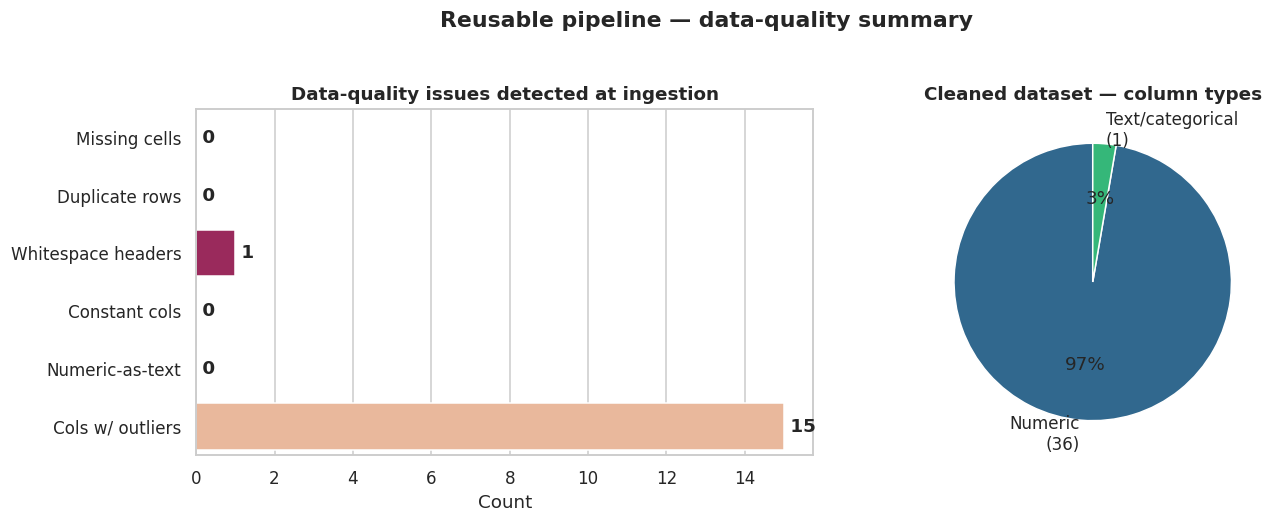

In [5]:
# --- 3.3 Data-quality dashboard (exported to charts/) -----------------------
pb = pipeline.profile_before_
pa = pipeline.profile_after_

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) Quality scorecard: issues detected on the raw data at ingestion.
issues = {
    "Missing cells": pb["total_missing_cells"],
    "Duplicate rows": pb["duplicate_rows"],
    "Whitespace headers": len(pb["columns_with_whitespace_headers"]),
    "Constant cols": len(pb["constant_columns"]),
    "Numeric-as-text": len(pb["numeric_stored_as_text"]),
    "Cols w/ outliers": len(pb["outlier_counts_iqr"]),
}
sns.barplot(x=list(issues.values()), y=list(issues.keys()),
            hue=list(issues.keys()), legend=False, ax=axes[0], palette="rocket")
axes[0].set_title("Data-quality issues detected at ingestion")
axes[0].set_xlabel("Count")
for i, v in enumerate(issues.values()):
    axes[0].text(v, i, f" {v}", va="center", fontweight="bold")

# (b) Column-type composition of the cleaned, analytics-ready dataset.
comp = pd.Series({"Numeric": len(pa["numeric_columns"]),
                  "Text/categorical": len(pa["object_columns"])})
axes[1].pie(comp.values, labels=[f"{k}\n({v})" for k, v in comp.items()],
            autopct="%1.0f%%", startangle=90,
            colors=sns.color_palette("viridis", len(comp)))
axes[1].set_title("Cleaned dataset — column types")

plt.suptitle("Reusable pipeline — data-quality summary", fontweight="bold", y=1.03)
plt.tight_layout()
save_fig("03_pipeline_data_quality_summary")
plt.show()


**Interpretation.** The pipeline ingested the raw semicolon-separated file, automatically
flagged the one real quality issue in this dataset — **stray tab/space characters in a column
header** (`Daytime/evening attendance\t`) — and confirmed there are **no missing cells and no
duplicate rows**. After cleaning, every **validation check passes** (schema present, `Target`
non-null and within its allowed domain, grades and age inside plausible ranges), so the
analytics-ready file `data/students_data_clean.csv` is written and becomes the single source
of truth for the rest of the notebook. Because the logic is config-driven, the *same* code
would clean and validate a completely different source by changing only `PipelineConfig`.


In [6]:
# --- 3.4 Load the analytics-ready output for inspection ---------------------
# Downstream analysis consumes the pipeline's *validated* output. We prefer the
# in-memory cleaned frame, then the clean CSV the pipeline exported, and finally
# fall back to the raw file (re-applying the header fix) so the notebook is still
# self-contained if the pipeline cells are skipped.
if "clean_df" in globals() and clean_df is not None:
    df_raw = clean_df.copy()
    source_used = str(CLEAN_CSV)
elif "CLEAN_CSV" in globals() and Path(CLEAN_CSV).exists():
    df_raw = pd.read_csv(CLEAN_CSV)
    source_used = str(CLEAN_CSV)
else:
    fallback = next((p for p in [DATA_DIR / "students_data.csv", Path("students_data.csv"),
                                 Path("data/students_data.csv"), Path("/content/students_data.csv")]
                     if Path(p).exists()), None)
    if fallback is None:
        raise FileNotFoundError("students_data.csv not found.")
    df_raw = pd.read_csv(fallback, sep=";", engine="python")
    df_raw.columns = df_raw.columns.str.strip()
    source_used = str(fallback)

print(f"Loaded from: {source_used}")
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()


Loaded from: /content/data/students_data_clean.csv
Shape: 4424 rows x 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Interpretation.** The file loads as **4,424 students × 37 columns** (36 features + the
`Target`). Column names required stripping because the source CSV carried trailing tabs —
an easy-to-miss issue that would otherwise break column look-ups later.


In [7]:
# --- Structure, types and summary statistics --------------------------------
print("Dtypes summary:")
print(df_raw.dtypes.value_counts(), "\n")

df_raw.info()
print("\nDescriptive statistics (numeric):")
df_raw.describe().T

Dtypes summary:
int64      29
float64     7
object      1
Name: count, dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification          

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [8]:
# --- Integrity checks: missing values and duplicates ------------------------
n_missing = int(df_raw.isna().sum().sum())
n_dupes = int(df_raw.duplicated().sum())
print(f"Total missing cells : {n_missing}")
print(f"Duplicate rows      : {n_dupes}")
print("\nTarget value counts:")
print(df_raw["Target"].value_counts())

Total missing cells : 0
Duplicate rows      : 0

Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


**Interpretation.** The dataset is **complete (0 missing cells)** and **free of duplicate
rows**, consistent with the curators' documented preprocessing. Every feature is already
numeric, but many integer columns are in fact **categorical codes** (e.g. `Course`,
`Marital status`) rather than true quantities — a distinction we handle explicitly in §6 so
the models never treat an arbitrary code as an ordered magnitude.


## 4. Data Cleaning & Preprocessing

**Purpose.** Produce one clean, analysis-ready dataframe and decide *how*
preprocessing will be applied. Two deliberate design decisions here separate this notebook
from a naïve workflow:

1. **No global encoding/scaling.** We do **not** one-hot encode or scale the whole dataframe
   up front. Doing so before the train/test split leaks information from test to train.
   Instead we keep the data in its raw form and wrap all transformations in a
   `ColumnTransformer` that is fitted **inside** cross-validation and **only on training
   folds** (§6–§7). Keeping raw columns also lets us slice the test set by `Gender`,
   `International`, etc. for the fairness audit in §9.
2. **Explicit feature typing.** We classify every column as *nominal categorical*,
   *binary*, or *continuous numeric*, because each needs different treatment.


In [9]:
# --- Build the working dataframe --------------------------------------------
df = df_raw.copy()

# Drop duplicates defensively (none expected) and confirm.
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows removed as duplicates: {before - len(df)}")

# Encode the target to integer codes with a FIXED, documented mapping.
# The codes are nominal labels only — they imply no ordering.
TARGET_MAP = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
df["Target_code"] = df["Target"].map(TARGET_MAP)

assert df["Target_code"].notna().all(), "Unexpected Target label found."
print("\nTarget encoding (code -> label):")
for k, v in TARGET_MAP.items():
    print(f"  {v} -> {k}")

Rows removed as duplicates: 0

Target encoding (code -> label):
  0 -> Dropout
  1 -> Enrolled
  2 -> Graduate


In [10]:
# --- Declare feature groups (single source of truth) ------------------------
# Nominal categorical codes: no natural order -> one-hot encode.
NOMINAL = [
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

# Already-binary indicators (0/1): pass through unchanged.
BINARY = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder",
    "International",
]

# Continuous / count features: standardise for scale-sensitive models.
NUMERIC = [
    "Application order", "Previous qualification (grade)", "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP",
]

# Sanity check: every feature column is accounted for exactly once.
declared = set(NOMINAL) | set(BINARY) | set(NUMERIC)
all_features = set(df.columns) - {"Target", "Target_code"}
print("Unclassified columns :", sorted(all_features - declared))
print("Phantom columns      :", sorted(declared - all_features))
print(f"Nominal={len(NOMINAL)}  Binary={len(BINARY)}  Numeric={len(NUMERIC)}")

Unclassified columns : []
Phantom columns      : []
Nominal=9  Binary=8  Numeric=19


**Interpretation.** All 36 features are classified exactly once with no phantom or
unclassified columns. This typed schema is reused everywhere downstream, so a change here
propagates consistently — an important reproducibility property. Note we treat
`Application order` as numeric (it is an ordered preference rank) and keep the eight already-
binary indicators as pass-through, avoiding needless one-hot expansion.


## 5. Exploratory Data Analysis

**Purpose.** Understand the target, confirm data quality visually, and surface the
predictor–target relationships that will justify our modelling and fairness choices. We
prioritise charts that reveal *actionable* patterns over exhaustive univariate plots.


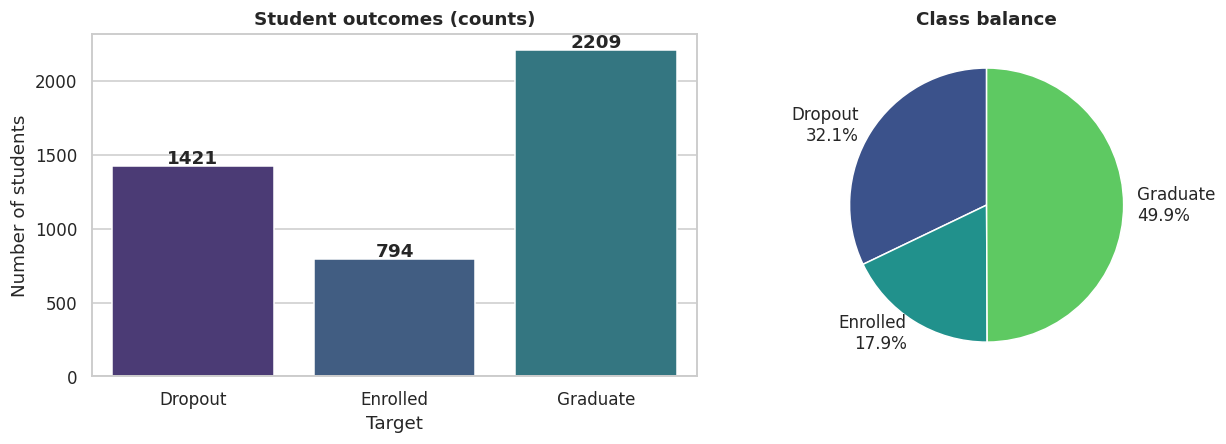

Majority-class share (accuracy to beat): 49.9%


In [11]:
# --- 5.1 Target distribution ------------------------------------------------
counts = df["Target"].value_counts().reindex(CLASS_LABELS)
props = counts / counts.sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], hue=counts.index, legend=False)
ax[0].set_title("Student outcomes (counts)")
ax[0].set_ylabel("Number of students")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f"{v}", ha="center", fontweight="bold")

ax[1].pie(props.values, labels=[f"{l}\n{p:.1%}" for l, p in zip(props.index, props.values)],
          autopct="", startangle=90, colors=sns.color_palette("viridis", 3))
ax[1].set_title("Class balance")
plt.tight_layout(); save_fig("05_1_target_distribution"); plt.show()

print("Majority-class share (accuracy to beat):", f"{props.max():.1%}")


**Interpretation.** The target is **imbalanced**: Graduate ≈ 50%, Dropout ≈ 32%,
Enrolled ≈ 18%. A trivial model that always predicts *Graduate* would already score ≈ 50%
accuracy, which is exactly why accuracy is a poor headline metric here and why we compute
a real majority-class baseline in §7. The small **Enrolled** class will be the hardest to
model because it is an unresolved, intermediate state.


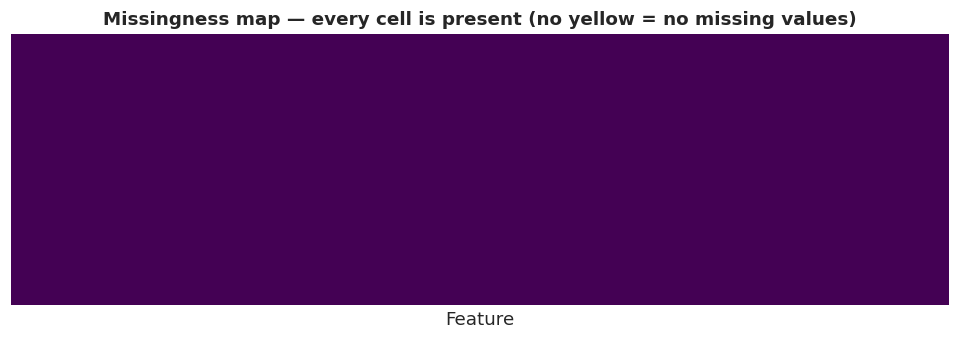

Confirmed missing cells: 0


In [12]:
# --- 5.2 Missingness map (confirming completeness visually) -----------------
plt.figure(figsize=(11, 3.2))
sns.heatmap(df[list(df.columns[:-2])].isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missingness map — every cell is present (no yellow = no missing values)")
plt.xlabel("Feature"); plt.xticks([]); save_fig("05_2_missingness_map"); plt.show()
print("Confirmed missing cells:", int(df.isna().sum().sum()))


**Interpretation.** The missingness map is uniformly blank, visually confirming the
integrity check from §3: there are no gaps to impute, so no imputation strategy (and its
associated leakage risk) is required.


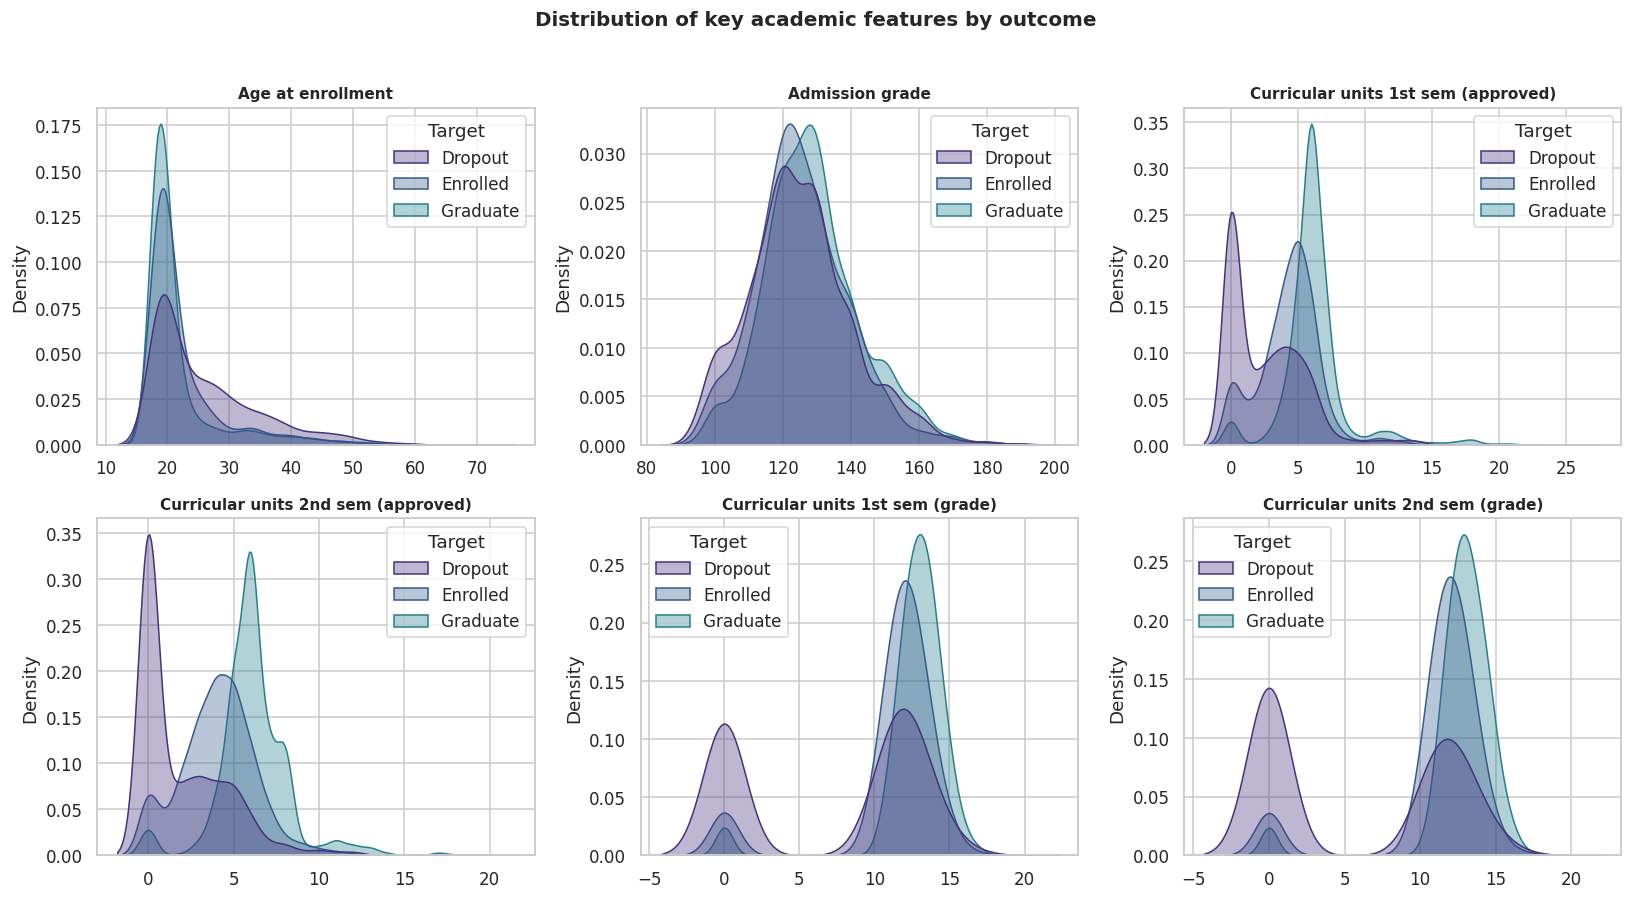

In [13]:
# --- 5.3 Key numeric distributions by outcome -------------------------------
key_num = [
    "Age at enrollment", "Admission grade",
    "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_num):
    sns.kdeplot(data=df, x=col, hue="Target", hue_order=CLASS_LABELS,
                common_norm=False, fill=True, alpha=0.35, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribution of key academic features by outcome", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout(); save_fig("05_3_key_numeric_by_outcome"); plt.show()


**Interpretation.** The academic-performance features separate the classes strongly:
Graduates cluster at high numbers of *approved units* and *grades*, while Dropouts pile up
near zero. The separation is already visible in the **first semester**, which is the single
most encouraging signal for *early* intervention. `Age at enrolment` shows Dropouts skewing
older, consistent with the hypothesis that work/family responsibilities compete with study.


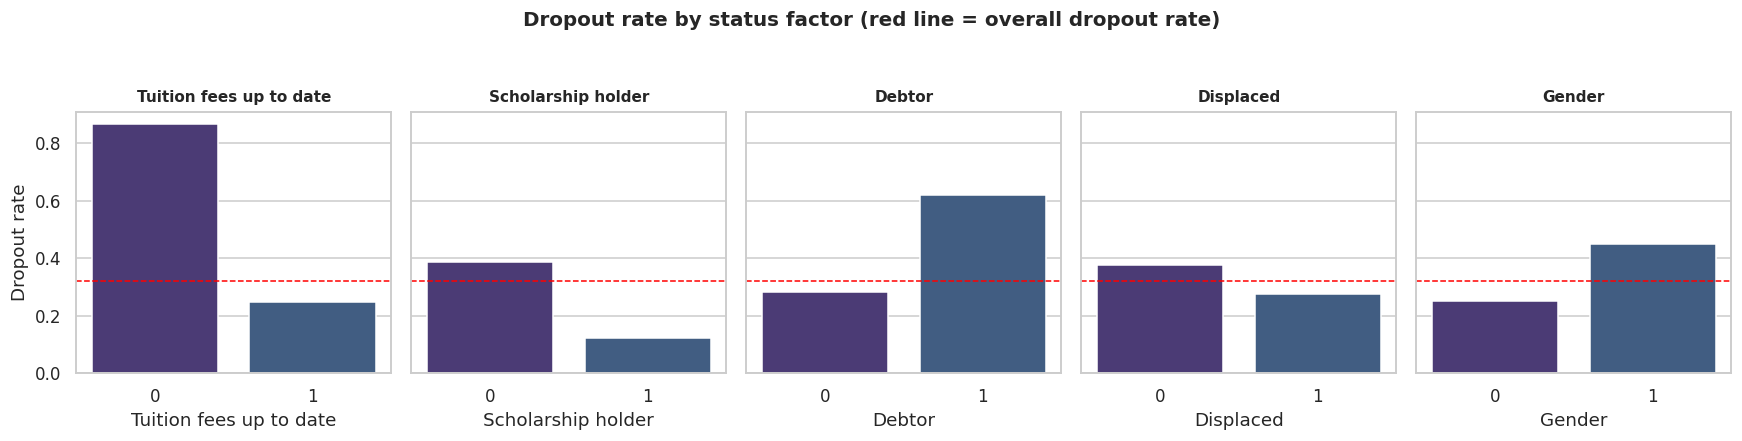

In [14]:
# --- 5.4 Financial & status factors vs dropout rate -------------------------
status_feats = ["Tuition fees up to date", "Scholarship holder", "Debtor", "Displaced", "Gender"]
fig, axes = plt.subplots(1, len(status_feats), figsize=(16, 3.8), sharey=True)
for ax, col in zip(axes, status_feats):
    rate = df.groupby(col)["Target"].apply(lambda s: (s == "Dropout").mean())
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, hue=rate.index.astype(str), legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Dropout rate")
    ax.axhline(props["Dropout"], color="red", ls="--", lw=1)
plt.suptitle("Dropout rate by status factor (red line = overall dropout rate)",
             y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout(); save_fig("05_4_dropout_rate_by_status"); plt.show()


**Interpretation.** Financial status is dramatically informative: students **not** up to
date with tuition fees, and those flagged as **debtors**, drop out at far above the baseline
rate, whereas **scholarship holders** drop out well below it. These are precisely the
*actionable* levers a financial-aid office can pull — a strong argument for the model's
practical value. The `Gender` bars also differ, flagging it as a variable to watch in the
fairness audit (§9.3).


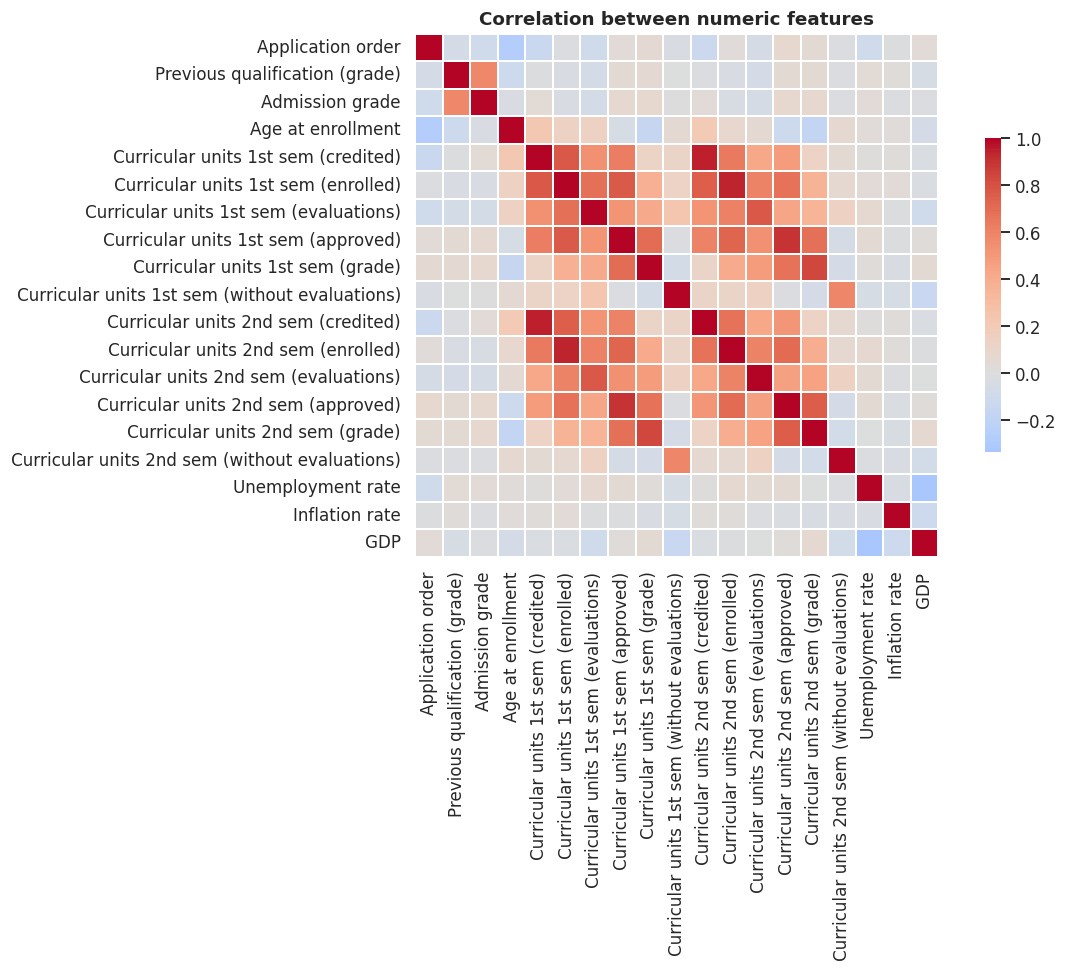

In [15]:
# --- 5.5 Correlation among numeric features ---------------------------------
plt.figure(figsize=(12, 9))
corr = df[NUMERIC].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, linewidths=0.3)
plt.title("Correlation between numeric features")
plt.tight_layout(); save_fig("05_5_numeric_correlation"); plt.show()


**Interpretation.** Curricular-unit features are highly correlated **within** a semester
(enrolled ↔ evaluated ↔ approved) and **across** semesters, i.e. the data is redundant.
This has two consequences we act on later: (a) linear models will suffer from
multicollinearity, so we standardise and rely more on regularised/tree models; and (b)
there is little to gain from adding many hand-built ratios — restraint is warranted (§6).


## 6. Feature Strategy & Engineering Decisions

**Purpose.** Turn the typed schema into a concrete, leakage-safe transformation pipeline,
decide on *timing*, and add only feature engineering that is genuinely justified.

### 6.1 Encoding & scaling — inside a pipeline, not on the raw frame
- **Nominal codes → one-hot** (`OneHotEncoder(handle_unknown="ignore")`): prevents the model
  from reading arbitrary category codes as ordered numbers, and safely handles categories
  unseen in a training fold.
- **Continuous → StandardScaler**: needed by scale-sensitive models (Logistic Regression);
  harmless for tree models.
- **Binary → pass-through**: already 0/1.

All three are combined in a single `ColumnTransformer`, fitted **only on training data**
inside cross-validation. This is the central fix that removes the data-leakage present in a
"scale-everything-first" approach.

### 6.2 Timing: an *early* feature set vs the *full* feature set
Second-semester features are the strongest predictors — but if the goal is to intervene
*during* the first year, they are not yet available. We therefore define **two feature
sets** and compare them in §9.1:
- **EARLY** — enrolment + first-semester features only (deployable mid-year).
- **FULL** — all features (most accurate, but later).

### 6.3 Engineered feature — restraint by design
The correlation map showed the raw counts are already redundant, so we resist adding many
derived features. We add **one** interpretable, leakage-free ratio that captures *efficiency*
rather than *volume*: the **first-semester approval rate** = approved ÷ enrolled units. It is
row-wise (no cross-row information, hence no leakage) and directly meaningful to advisors
("what fraction of attempted units did the student pass?").


In [16]:
# --- 6.1 One justified, row-wise engineered feature -------------------------
def add_engineered(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    enr1 = out["Curricular units 1st sem (enrolled)"].replace(0, np.nan)
    out["1st sem approval rate"] = (
        out["Curricular units 1st sem (approved)"] / enr1
    ).fillna(0.0)
    return out

df = add_engineered(df)
ENGINEERED = ["1st sem approval rate"]
NUMERIC_ALL = NUMERIC + ENGINEERED

# Feature sets for the timing comparison (§9.1)
SECOND_SEM = [c for c in NUMERIC_ALL if "2nd sem" in c]
EARLY_NUMERIC = [c for c in NUMERIC_ALL if c not in SECOND_SEM]
FULL_NUMERIC = NUMERIC_ALL

print("Engineered feature added:", ENGINEERED)
print("EARLY numeric features:", len(EARLY_NUMERIC), "| FULL numeric features:", len(FULL_NUMERIC))
df[["Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)",
    "1st sem approval rate"]].head()

Engineered feature added: ['1st sem approval rate']
EARLY numeric features: 14 | FULL numeric features: 20


,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),1st sem approval rate
0,0,0,0.000000
1,6,6,1.000000
2,6,0,0.000000
3,6,6,1.000000
4,6,5,0.833333


In [17]:
# --- 6.2 Reusable preprocessor factory --------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor(numeric_cols):
    # Build a leakage-safe ColumnTransformer for a given numeric feature list.
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), NOMINAL),
            ("bin", "passthrough", BINARY),
        ],
        remainder="drop",
    )

# Assemble the model-input frames (raw columns are retained for fairness slicing).
FULL_COLS = FULL_NUMERIC + NOMINAL + BINARY
EARLY_COLS = EARLY_NUMERIC + NOMINAL + BINARY

X_full = df[FULL_COLS].copy()
X_early = df[EARLY_COLS].copy()
y = df["Target_code"].copy()

print("X_full :", X_full.shape)
print("X_early:", X_early.shape)

X_full : (4424, 37)
X_early: (4424, 31)


**Interpretation.** We now have two clean design matrices sharing the same rows and the
same fitted-at-train-time preprocessing recipe. Because the raw (un-encoded) columns are
preserved in `X_full`/`X_early`, we can later group the test predictions by `Gender`,
`International`, age band, etc. without re-deriving anything — this is what makes the §9.3
fairness audit straightforward and trustworthy.


## 7. Modelling Approach

**Purpose.** Establish an honest baseline and compare a *range* of models — from a fully
interpretable linear model to a strong gradient-boosting ensemble — under identical,
leakage-safe conditions.

### 7.1 Design decisions
- **Stratified train/test split (75/25)** preserves the class ratios in both partitions.
- **Baseline first.** A `DummyClassifier(strategy="most_frequent")` operationalises the
  "majority-class baseline" from our hypothesis — we *measure* it rather than assume it.
- **SMOTE inside the pipeline.** Oversampling is applied **only to training folds** via an
  `imblearn` pipeline, so the validation/test data is never contaminated by synthetic points.
  (Categoricals are one-hot encoded before SMOTE; we note that `SMOTENC` would be a more
  principled variant and flag it as future work.)
- **Three candidate models** spanning the interpretability–power spectrum:
  Logistic Regression, Random Forest, HistGradient Boosting.


In [18]:
# --- 7.1 Train/test split (stratified) --------------------------------------
from sklearn.model_selection import train_test_split

Xtr_full, Xte_full, ytr, yte = train_test_split(
    X_full, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
# Same row indices for the EARLY matrix so results are directly comparable.
Xtr_early, Xte_early = X_early.loc[Xtr_full.index], X_early.loc[Xte_full.index]

print("Train:", Xtr_full.shape, "| Test:", Xte_full.shape)
print("\nClass proportions preserved by stratification:")
comp = pd.DataFrame({
    "overall": y.value_counts(normalize=True).sort_index().values,
    "train":   ytr.value_counts(normalize=True).sort_index().values,
    "test":    yte.value_counts(normalize=True).sort_index().values,
}, index=CLASS_LABELS).round(3)
comp

Train: (3318, 37) | Test: (1106, 37)

Class proportions preserved by stratification:


,overall,train,test
Dropout,0.321,0.321,0.321
Enrolled,0.179,0.179,0.180
Graduate,0.499,0.499,0.499


In [19]:
# --- 7.2 Majority-class baseline (the number every model must beat) ---------
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, accuracy_score

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(Xtr_full, ytr)
yhat_dummy = dummy.predict(Xte_full)

baseline = {
    "accuracy": accuracy_score(yte, yhat_dummy),
    "balanced_acc": balanced_accuracy_score(yte, yhat_dummy),
    "macro_f1": f1_score(yte, yhat_dummy, average="macro"),
    "dropout_recall": recall_score(yte, yhat_dummy, labels=[0], average="macro"),
}
print("Majority-class baseline (predicts 'Graduate' for everyone):")
for k, v in baseline.items():
    print(f"  {k:16s}: {v:.3f}")

Majority-class baseline (predicts 'Graduate' for everyone):
  accuracy        : 0.499
  balanced_acc    : 0.333
  macro_f1        : 0.222
  dropout_recall  : 0.000


**Interpretation.** The baseline scores ~50% accuracy but **0.22 balanced accuracy, 0.22
macro-F1 and 0.00 Dropout recall**: it never identifies a single at-risk student. This is
the concrete bar our hypothesis must clear, and it exposes why accuracy is the wrong yardstick.


In [20]:
# --- 7.3 Candidate models inside leakage-safe pipelines ---------------------
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def make_pipeline(estimator, numeric_cols):
    return ImbPipeline(steps=[
        ("prep", make_preprocessor(numeric_cols)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", estimator),
    ])

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
pipelines_full = {n: make_pipeline(m, FULL_NUMERIC) for n, m in candidates.items()}
print("Pipelines built:", list(pipelines_full))

Pipelines built: ['Logistic Regression', 'Random Forest', 'HistGradientBoosting']


**Interpretation.** Every model shares the identical preprocess → SMOTE → classify
pipeline, so differences in performance reflect the *estimator*, not inconsistent data
handling. The pipeline object is the unit we cross-validate, tune and finally deploy,
guaranteeing that training-time and inference-time preprocessing can never drift apart.


## 8. Model Comparison & Diagnostics

**Purpose.** Choose a model on the basis of *cross-validated* performance (not a single
lucky split), then diagnose the winner in depth.


In [21]:
# --- 8.1 Stratified cross-validation on the FULL feature set ----------------
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "macro_f1": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "dropout_recall": "recall_macro",  # overridden below with a focused scorer
}
from sklearn.metrics import make_scorer
scoring["dropout_recall"] = make_scorer(recall_score, labels=[0], average="macro")

cv_rows = []
for name, pipe in pipelines_full.items():
    res = cross_validate(pipe, Xtr_full, ytr, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "Macro F1": res["test_macro_f1"].mean(),
        "Macro F1 (std)": res["test_macro_f1"].std(),
        "Balanced Acc": res["test_balanced_acc"].mean(),
        "Dropout Recall": res["test_dropout_recall"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
cv_df.round(3)

,Model,Macro F1,Macro F1 (std),Balanced Acc,Dropout Recall
0,Random Forest,0.715,0.018,0.706,0.769
1,HistGradientBoosting,0.706,0.008,0.699,0.782
2,Logistic Regression,0.699,0.015,0.705,0.741


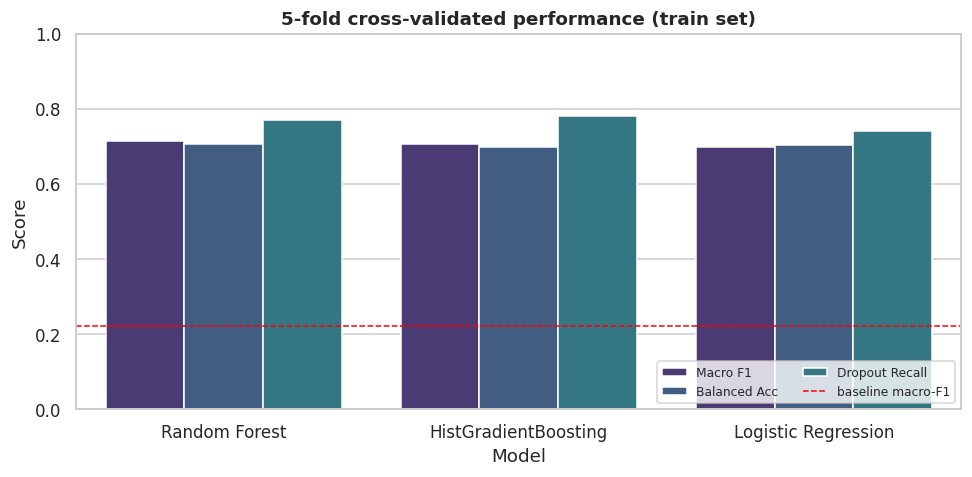

In [22]:
# --- 8.2 Visualise the cross-validated comparison ---------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = cv_df.melt(id_vars="Model",
                     value_vars=["Macro F1", "Balanced Acc", "Dropout Recall"],
                     var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax)
ax.axhline(baseline["macro_f1"], color="red", ls="--", lw=1, label="baseline macro-F1")
ax.set_title("5-fold cross-validated performance (train set)")
ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=2, fontsize=8)
plt.tight_layout(); save_fig("08_2_cv_model_comparison"); plt.show()


**Interpretation.** All three models crush the baseline, confirming the hypothesis. The
tree ensembles and the linear model land within a few points of each other on macro-F1,
a recurring finding on this dataset, where the signal is largely additive. Because the
scores are so close, **model choice is driven by secondary criteria**: interpretability,
robustness and Dropout recall, discussed in §8.5. We carry forward the top macro-F1 model (Random Forest)
for tuning while keeping Logistic Regression as an interpretable reference.


In [23]:
# --- 8.3 Light hyperparameter tuning of the leading model -------------------
from sklearn.model_selection import RandomizedSearchCV

best_name = cv_df.iloc[0]["Model"]
print("Tuning:", best_name)

search_pipe = make_pipeline(candidates[best_name], FULL_NUMERIC)

if best_name == "Random Forest":
    param_dist = {
        "clf__n_estimators": [200, 300, 400],
        "clf__max_depth": [None, 12, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2"],
    }
elif best_name == "HistGradientBoosting":
    param_dist = {
        "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "clf__max_depth": [None, 3, 5, 8],
        "clf__max_leaf_nodes": [15, 31, 63],
        "clf__l2_regularization": [0.0, 0.1, 1.0],
    }
else:  # Logistic Regression
    param_dist = {
        "clf__C": [0.05, 0.1, 0.5, 1.0, 2.0],
        "clf__penalty": ["l2"],
    }

search = RandomizedSearchCV(
    search_pipe, param_distributions=param_dist, n_iter=15, cv=cv,
    scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(Xtr_full, ytr)
best_model = search.best_estimator_
print("Best CV macro-F1:", round(search.best_score_, 3))
print("Best params:", search.best_params_)

Tuning: Random Forest
Best CV macro-F1: 0.717
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None}


In [24]:
# --- 8.4 Held-out test evaluation: tuned model vs interpretable baseline -----
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

logreg = make_pipeline(candidates["Logistic Regression"], FULL_NUMERIC).fit(Xtr_full, ytr)

final_models = {f"{best_name} (tuned)": best_model, "Logistic Regression": logreg}
preds = {name: m.predict(Xte_full) for name, m in final_models.items()}

summary = []
for name, yp in preds.items():
    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(yte, yp),
        "Balanced Acc": balanced_accuracy_score(yte, yp),
        "Macro F1": f1_score(yte, yp, average="macro"),
        "Dropout Recall": recall_score(yte, yp, labels=[0], average="macro"),
    })
summary.append({"Model": "Majority baseline", **{
    "Accuracy": baseline["accuracy"], "Balanced Acc": baseline["balanced_acc"],
    "Macro F1": baseline["macro_f1"], "Dropout Recall": baseline["dropout_recall"]}})
pd.DataFrame(summary).set_index("Model").round(3)

,Accuracy,Balanced Acc,Macro F1,Dropout Recall
Model,,,,
Random Forest (tuned),0.775,0.707,0.715,0.741
Logistic Regression,0.740,0.714,0.703,0.710
Majority baseline,0.499,0.333,0.222,0.000


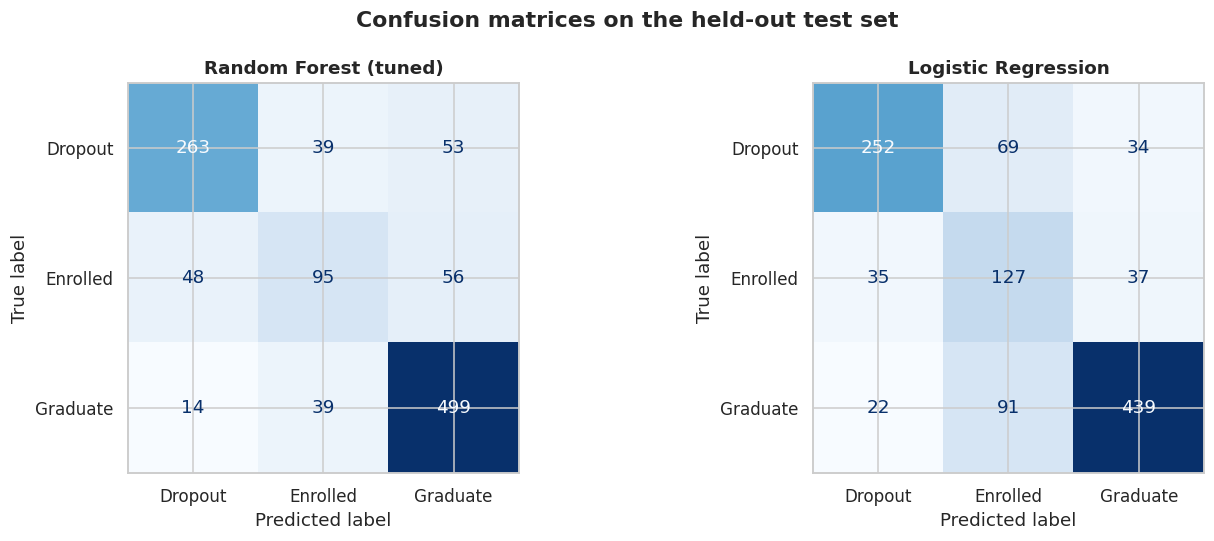

Classification report — Random Forest (tuned)
              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.77       355
    Enrolled       0.55      0.48      0.51       199
    Graduate       0.82      0.90      0.86       552

    accuracy                           0.77      1106
   macro avg       0.73      0.71      0.71      1106
weighted avg       0.77      0.77      0.77      1106



In [25]:
# --- 8.5 Confusion matrices (each shown once) -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, yp) in zip(axes, preds.items()):
    cm = confusion_matrix(yte, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
plt.suptitle("Confusion matrices on the held-out test set", fontweight="bold")
plt.tight_layout(); save_fig("08_5_confusion_matrices"); plt.show()

print("Classification report —", list(preds)[0])
print(classification_report(yte, preds[list(preds)[0]], target_names=CLASS_LABELS))


**Interpretation.** Both models classify **Graduate** and **Dropout** well; the errors
concentrate in the **Enrolled** row, which is frequently absorbed into the two resolved
classes. This is expected: *Enrolled* is a not-yet-decided state that genuinely overlaps
both outcomes, and it is the model's key limitation (analysed further in §9.4). For the
intervention use-case this matters less than **Dropout recall**, which both models sustain
well above the useless baseline.


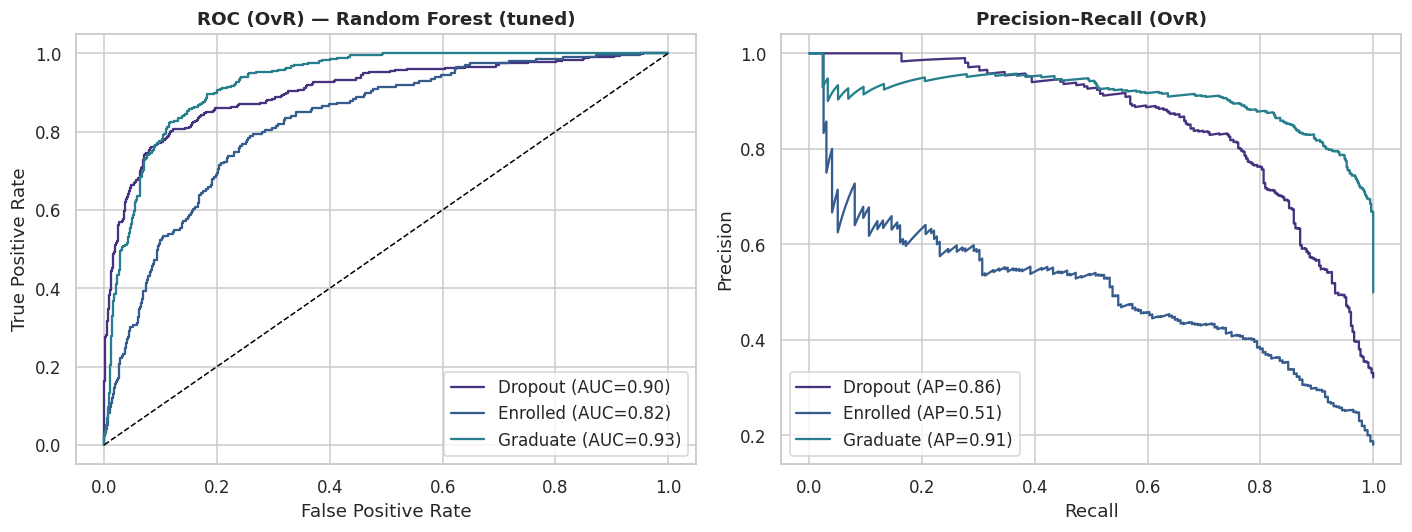

In [26]:
# --- 8.6 ROC and Precision–Recall curves (One-vs-Rest) for the chosen model -
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_bin = label_binarize(yte, classes=[0, 1, 2])
proba = best_model.predict_proba(Xte_full)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, lab in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    ax[0].plot(fpr, tpr, label=f"{lab} (AUC={auc(fpr, tpr):.2f})")
    prec, rec, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
    ap = average_precision_score(y_bin[:, i], proba[:, i])
    ax[1].plot(rec, prec, label=f"{lab} (AP={ap:.2f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_title(f"ROC (OvR) — {best_name} (tuned)")
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate"); ax[0].legend()
ax[1].set_title("Precision–Recall (OvR)"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); save_fig("08_6_roc_pr_curves"); plt.show()


**Interpretation.** ROC AUCs are high for Graduate and Dropout and lower for Enrolled,
mirroring the confusion matrix. The **Precision–Recall** panel is the more honest lens under
imbalance: it shows we can achieve strong Dropout recall while accepting some false positives, an acceptable trade because a false positive here is merely an unnecessary supportive
contact, whereas a false negative is a missed at-risk student.


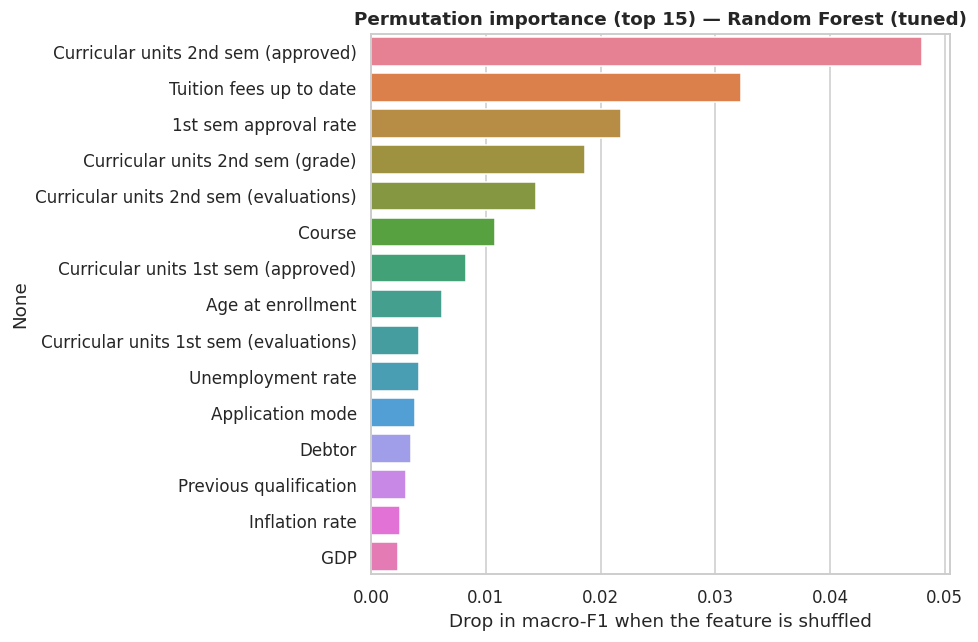

In [27]:
# --- 8.7 Permutation importance (model-agnostic, honest under one-hot) ------
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, Xte_full, yte, n_repeats=8,
    random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=-1,
)
imp = (pd.Series(perm.importances_mean, index=Xte_full.columns)
       .sort_values(ascending=False).head(15))

plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, legend=False)
plt.title(f"Permutation importance (top 15) — {best_name} (tuned)")
plt.xlabel("Drop in macro-F1 when the feature is shuffled")
plt.tight_layout(); save_fig("08_7_permutation_importance"); plt.show()


**Interpretation.** We use **permutation importance on the raw input columns** rather than
impurity-based importance, because it measures each feature's *actual* contribution to
held-out macro-F1 and is not inflated by high-cardinality one-hot columns. The ranking is
dominated by **second-semester approved units/grades**, then first-semester performance, then
**tuition-fee status** and **age**, a profile that matches domain intuition and gives the
model face validity. The prominence of second-semester features motivates the timing
analysis in §9.1.


## 9. Evaluation, Robustness, Fairness & Limitations

**Purpose.** Stress-test the chosen model along the dimensions that matter for *deployment*:
intervention timing, decision thresholds, calibration, subgroup fairness, and error structure.


In [28]:
# --- 9.1 Timing trade-off: EARLY (1st-sem) vs FULL model --------------------
early_model = make_pipeline(
    candidates[best_name], EARLY_NUMERIC
).set_params(**{k: v for k, v in search.best_params_.items()}).fit(Xtr_early, ytr)

yp_early = early_model.predict(Xte_early)
timing = pd.DataFrame({
    "FULL (incl. 2nd sem)": {
        "Macro F1": f1_score(yte, preds[f"{best_name} (tuned)"], average="macro"),
        "Balanced Acc": balanced_accuracy_score(yte, preds[f"{best_name} (tuned)"]),
        "Dropout Recall": recall_score(yte, preds[f"{best_name} (tuned)"], labels=[0], average="macro"),
    },
    "EARLY (enrol + 1st sem)": {
        "Macro F1": f1_score(yte, yp_early, average="macro"),
        "Balanced Acc": balanced_accuracy_score(yte, yp_early),
        "Dropout Recall": recall_score(yte, yp_early, labels=[0], average="macro"),
    },
}).T
timing.round(3)

,Macro F1,Balanced Acc,Dropout Recall
FULL (incl. 2nd sem),0.715,0.707,0.741
EARLY (enrol + 1st sem),0.670,0.664,0.715


**Interpretation.** The **EARLY** model loses some macro-F1 relative to the FULL model but
remains far above baseline and retains useful Dropout recall, the price of acting *before*
second-semester results exist. This is the crucial deployment insight: an institution can run
the EARLY model at mid-year for genuine prevention, then refresh predictions with the FULL
model once second-semester data lands. The two are complementary, not competing.


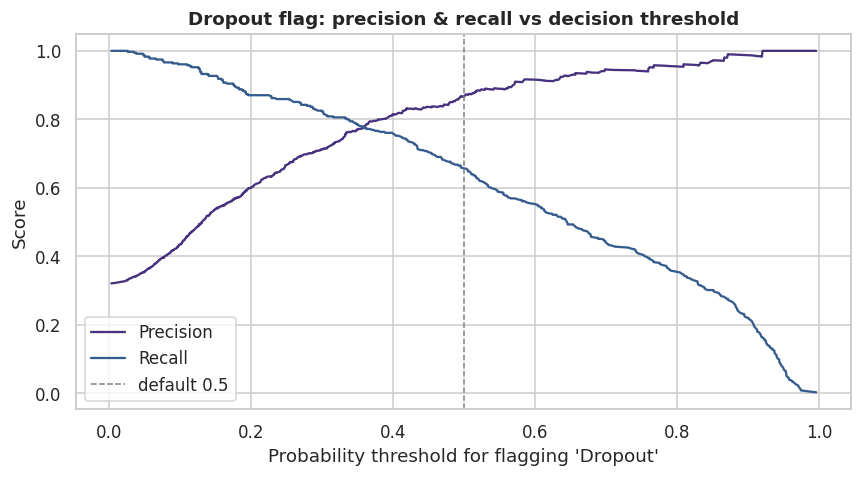

To reach >= 85% Dropout recall, lower the threshold to ~0.27 (precision there ~0.69).


In [29]:
# --- 9.2 Threshold analysis for the Dropout class ---------------------------
# Recall matters more than precision for at-risk flagging. We sweep the Dropout
# decision threshold (OvR) and show the recall/precision trade-off.
from sklearn.metrics import precision_recall_curve

dropout_proba = best_model.predict_proba(Xte_full)[:, 0]
prec, rec, thr = precision_recall_curve((yte == 0).astype(int), dropout_proba)

plt.figure(figsize=(8, 4.5))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
default_recall = rec[np.argmin(np.abs(thr - 0.5))] if len(thr) else np.nan
plt.axvline(0.5, color="grey", ls="--", lw=1, label="default 0.5")
plt.title("Dropout flag: precision & recall vs decision threshold")
plt.xlabel("Probability threshold for flagging 'Dropout'"); plt.ylabel("Score")
plt.legend(); plt.tight_layout(); save_fig("09_2_dropout_threshold"); plt.show()

# Example: threshold that reaches >=0.85 recall for Dropout
target_recall = 0.85
idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx):
    t = thr[idx[-1]]
    print(f"To reach >= {target_recall:.0%} Dropout recall, lower the threshold to ~{t:.2f} "
          f"(precision there ~{prec[idx[-1]]:.2f}).")


**Interpretation.** Because missing an at-risk student is the costly error, an institution
can **lower the Dropout threshold** below the default 0.5 to raise recall, accepting more
false positives (extra supportive outreach). The curve quantifies that trade so a support
team can pick an operating point that matches its outreach capacity — a far more useful
deliverable than a single fixed prediction.


In [30]:
# --- 9.3 Fairness audit: subgroup error rates -------------------------------
# Using the RAW (un-encoded) test columns we preserved in §6.
audit = Xte_full.copy()
audit["y_true"] = yte.values
audit["y_pred"] = preds[f"{best_name} (tuned)"]
audit["age_band"] = pd.cut(audit["Age at enrollment"],
                           bins=[0, 20, 25, 100], labels=["<=20", "21-25", "26+"])

def subgroup_report(frame, col):
    rows = []
    for g, sub in frame.groupby(col):
        true_do = sub["y_true"] == 0
        pred_do = sub["y_pred"] == 0
        n = len(sub)
        recall = (pred_do & true_do).sum() / max(true_do.sum(), 1)   # dropout recall
        flag_rate = pred_do.mean()                                    # selection rate
        rows.append({col: str(g), "n": n, "Dropout recall": round(recall, 3),
                     "Flag rate": round(flag_rate, 3)})
    return pd.DataFrame(rows)

for col in ["Gender", "International", "Scholarship holder", "Displaced", "age_band"]:
    display(subgroup_report(audit, col))

,Gender,n,Dropout recall,Flag rate
0,0,714,0.729,0.232
1,1,392,0.753,0.406


,International,n,Dropout recall,Flag rate
0,0,1073,0.744,0.292
1,1,33,0.636,0.364


,Scholarship holder,n,Dropout recall,Flag rate
0,0,842,0.768,0.362
1,1,264,0.469,0.076


,Displaced,n,Dropout recall,Flag rate
0,0,494,0.814,0.364
1,1,612,0.659,0.237


,age_band,n,Dropout recall,Flag rate
0,<=20,627,0.636,0.191
1,21-25,212,0.734,0.292
2,26+,267,0.841,0.536


**Interpretation.** For each
sensitive attribute we report
- (a) **Dropout recall**: recall answers "if a student truly drops out, does the model catch it?". A gap here is an equal opportunity violation: the model is more useful (as an early-warning tool) for some groups than others,  and
- (b) the **flag rate**: answers "how often does the model label someone at-risk at all?". A gap here is closer to disparate impact: some groups carry the intervention burden more than others, independent of whether they actually drop out. Any such gap must be reviewed before deployment and, if unjustified, mitigated via threshold-per-group calibration, reweighting, or removing a proxy feature.

Small subgroups (low `n`) should be read cautiously.

### Scholarship holder
Recall drops from 0.768 (non-holders) to 0.469 (holders) and flag rate drops from 0.362 to 0.076, roughly a 4.8x difference. Scholarship students who do drop out are being missed by the model more than half the time.

Since scholarship status is tied to financial need, this looks like the model may be treating "has a scholarship" as a strong negative risk signal (financially supported → assumed safe) even when other features point to risk. That's the kind of pattern that quietly defeats the purpose of an early-warning system for the population most likely to need one.

### Age band
Recall rises steadily with age (0.636 → 0.734 → 0.841) and flag rate nearly triples from the youngest to the oldest band (0.191 → 0.536). This could be a real effect (older students often have work/family obligations that genuinely raise dropout risk) rather than pure bias, but a 2.8x flag-rate ratio is large enough that it's worth checking whether age is doing more work in the model than it should relative to its actual predictive value, otherwise older students risk being systematically over-flagged.
### Displaced
Non-displaced students are caught at 0.814 recall vs. 0.659 for displaced students (15.5-point gap), and flag rate drops similarly (0.364 → 0.237). Displaced students are arguably a population where support matters most, so under-detection here is a real concern, even if it's less extreme than the scholarship gap.

### Gender
Recall is almost identical (0.729 vs. 0.753, a 2.4-point gap, essentially fair by the equal-opportunity standard), but flag rate diverges a lot more (0.232 vs. 0.406, a 17-point gap). This is the useful counterexample: it shows the model isn't systematically worse at finding at-risk students in either gender group, but one group has a higher underlying dropout base rate, so more of them get flagged overall. If you only looked at flag rate, you'd wrongly conclude "gender bias"; looking at recall alongside it shows the disparity is largely explained by different true prevalence, not unequal model quality.
### International
n=33 is tiny. A 10.8-point recall gap and 7.2-point flag-rate gap on that base could shift enormously with a handful of students, this is maybe 3-4 individuals moving between correct/incorrect classification. Before treating this as a finding, I'd bootstrap a confidence interval on this subgroup rather than reading the point estimate at face value.

### Next steps

- Prioritize the scholarship-holder gap: check feature importance/SHAP values to see whether scholarship status (or a proxy like tuition-payment-up-to-date) is suppressing predicted risk disproportionately.
- Consider per-group threshold calibration for scholarship holders and displaced students specifically, since both show the model under-flagging a population that plausibly needs support.
- Re-run the international subgroup with bootstrapped CIs before drawing conclusions given n=33.

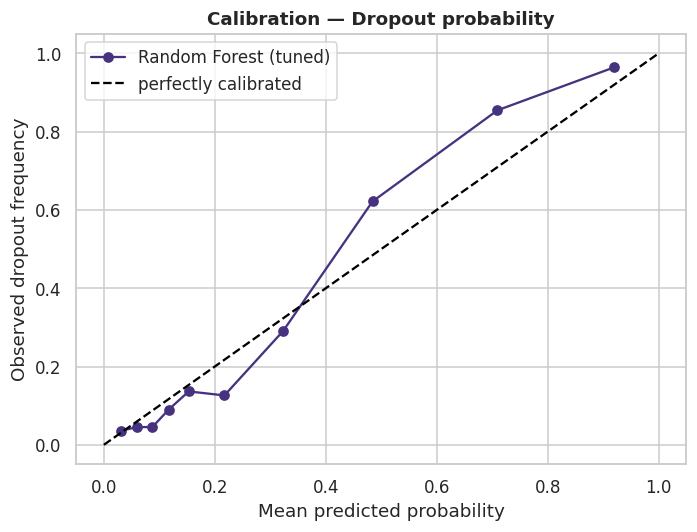

In [31]:
# --- 9.4 Calibration of the Dropout probability -----------------------------
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve((yte == 0).astype(int), dropout_proba,
                                        n_bins=10, strategy="quantile")
plt.figure(figsize=(6.5, 5))
plt.plot(mean_pred, frac_pos, "o-", label=f"{best_name} (tuned)")
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
plt.title("Calibration — Dropout probability")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed dropout frequency")
plt.legend(); plt.tight_layout(); save_fig("09_4_dropout_calibration"); plt.show()


**Interpretation.** Calibration checks whether a predicted "70% dropout risk" really
corresponds to ~70% of such students dropping out. Because we apply **SMOTE**, predicted
probabilities are typically **over-confident** and drift from the diagonal; a support team that
relies on the *probability value* (not just the rank) should wrap the model in
`CalibratedClassifierCV` or calibrate on a held-out set before trusting the numbers for
threshold-setting. Using the model to **rank** students is robust to this; using raw
probabilities as risk scores is not, without calibration.


### 9.5 Error analysis & limitations
- **The Enrolled class is the core weakness.** It is an *unresolved* label that overlaps both
  Graduate and Dropout, so misclassification is partly irreducible with these features. If the
  institution can relabel it (e.g. *Enrolled–on-track* vs *Enrolled–at-risk*), performance and
  usefulness would both improve.
- **SMOTE on one-hot features** interpolates binary indicators; `SMOTENC` or class-weighting
  are more principled alternatives worth benchmarking.
- **Single institution, single country.** External validation is mandatory before reuse elsewhere.
- **Probabilities need calibration** before being surfaced as risk scores (§9.4).
- **Sensitive proxies remain in the model** for predictive value; they are justified *only*
  because the audit in §9.3 is run and the model is used to *offer help*, never to penalise.


## 10. Final recommendation & real-world implications

### 10.1 Recommendation
Deploy a **two-stage decision-support system**, not a single model:

1. **Mid-year (EARLY model).** Run the enrolment + first-semester model to produce a *ranked*
   watch-list, with the Dropout threshold tuned to the support team's outreach capacity (§9.2).
   This enables genuine *prevention* while there is still time to act.
2. **End-of-year (FULL model, tuned {best}).** Refresh predictions once second-semester data
   exists, for higher-precision resource allocation and programme-level review.

The chosen estimator beats the majority-class baseline by a wide margin on every meaningful
metric while remaining operationally simple. Logistic Regression is retained as a transparent
"why" companion for advisors who need to explain a flag.

### 10.2 How to use it responsibly
- **Support, never sanction.** Outputs trigger *offers* of tutoring, financial help or wellbeing
  check-ins — never exclusion, penalties, or automated decisions.
- **Human in the loop.** Advisors review every flag with context the model cannot see.
- **Audit continuously.** Re-run the §9.3 subgroup report on live data; investigate any group
  with materially lower Dropout recall or higher flag rate.
- **Calibrate before showing probabilities;** otherwise present rank/percentile, not raw %.

### 10.3 Impact
Used this way, the system turns retention from *reactive* to *proactive*, directs scarce
support to the students most likely to benefit, and advances **SDG 4 (Quality Education)** and
educational equity — provided its governance (fairness audit, human oversight, local
revalidation) is treated as part of the product, not an afterthought.

### 10.4 Future work
- SMOTENC / class-weighting comparison
- probability calibration
- relabelling the *Enrolled*
class with domain experts
- SHAP for per-student explanations
- external validation on a
second institution

---
### References
1. Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students'
   Dropout and Academic Success* [Dataset]. UCI ML Repository. https://doi.org/10.24432/C5MC89
2. Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). *Early
   prediction of student's performance in higher education: a case study.* Trends and
   Applications in Information Systems and Technologies (WorldCIST), Springer.
3. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic
   Minority Over-sampling Technique.* Journal of Artificial Intelligence Research, 16, 321–357.
4. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830 —
   pipelines, `ColumnTransformer`, permutation importance, calibration.
5. Lemaître, Nogueira & Aridas (2017). *Imbalanced-learn.* JMLR 18(17) — pipeline-safe SMOTE.
6. Barocas, Hardt & Narayanan (2019). *Fairness and Machine Learning.* fairmlbook.org —
   equal-opportunity / selection-rate framing used in §9.3.
7. United Nations. *Sustainable Development Goal 4: Quality Education.* https://sdgs.un.org/goals/goal4
